# Task 3: Customer Churn Prediction (Bank Customers)

## DevelopersHub Corporation - Data Science & Analytics Internship

### Objective:
Identify customers who are likely to leave the bank based on their profile and banking behavior.

### Dataset:
Churn Modelling Dataset (Kaggle)

### Models Used:
- Logistic Regression
- Decision Tree Classifier

### Tools Used:
Python 3.10, pandas, matplotlib, seaborn, scikit-learn

In [1]:
# ============================
# Step 1: Import Required Libraries
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Set visualization style
sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ============================
# Step 2: Load the Churn Modelling Dataset
# ============================

df = pd.read_csv('Churn_Modelling.csv')

print("Dataset loaded successfully!")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset loaded successfully!
Total Rows: 10000
Total Columns: 14


In [3]:
# ============================
# Step 3: Display First 5 Rows
# ============================

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# ============================
# Step 4: Dataset Structure and Information
# ============================

# Shape
print("Dataset Shape:", df.shape)
print()

# Column Names and Data Types
print("Column Names and Data Types:")
print("-" * 50)
for col in df.columns:
    print(f"  {col:20s} -> {df[col].dtype}")
print()

# Statistical Summary
print("Statistical Summary:")
df.describe()

Dataset Shape: (10000, 14)

Column Names and Data Types:
--------------------------------------------------
  RowNumber            -> int64
  CustomerId           -> int64
  Surname              -> object
  CreditScore          -> int64
  Geography            -> object
  Gender               -> object
  Age                  -> int64
  Tenure               -> int64
  Balance              -> float64
  NumOfProducts        -> int64
  HasCrCard            -> int64
  IsActiveMember       -> int64
  EstimatedSalary      -> float64
  Exited               -> int64

Statistical Summary:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
# ============================
# Step 5: Detailed Dataset Info
# ============================

print("Dataset Info:")
print("=" * 50)
df.info()
print()

# Unique values in each column
print("\nUnique Values in Each Column:")
print("=" * 50)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    if df[col].dtype == 'object' or df[col].nunique() <= 5:
        print(f"   Values: {df[col].unique()}")
    print()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Unique Values in Each Column:
RowNumber: 10000 unique values

CustomerId: 1000

In [6]:
# ============================
# Step 6: Check for Missing Values
# ============================

print("Missing Values in Each Column:")
print("=" * 50)
print(df.isnull().sum())
print()
print(f"Total Missing Values: {df.isnull().sum().sum()}")

if df.isnull().sum().sum() == 0:
    print("\nNo missing values found! Dataset is clean.")

Missing Values in Each Column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Total Missing Values: 0

No missing values found! Dataset is clean.


In [7]:
# ============================
# Step 7: Clean and Prepare the Dataset
# ============================
# Drop unnecessary columns that won't help in prediction
# RowNumber, CustomerId, Surname are just identifiers

df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print("Dropped unnecessary columns: RowNumber, CustomerId, Surname")
print(f"\nRemaining columns: {df_clean.shape[1]}")
print("Columns:", df_clean.columns.tolist())
print()
print("Cleaned Dataset - First 5 Rows:")
df_clean.head()

Dropped unnecessary columns: RowNumber, CustomerId, Surname

Remaining columns: 11
Columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Cleaned Dataset - First 5 Rows:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Exploratory Data Analysis (EDA)

Visualizing key features to understand customer churn patterns:
1. Churn Distribution
2. Geography vs Churn
3. Gender vs Churn
4. Age Distribution by Churn
5. Balance and Salary Analysis
6. Correlation Heatmap

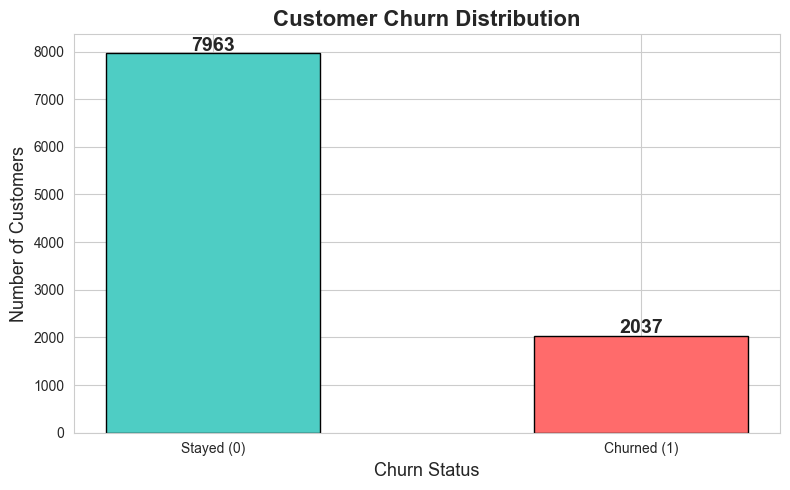

Stayed: 7963 customers (79.6%)
Churned: 2037 customers (20.4%)

The dataset is imbalanced - most customers stayed.


In [8]:
# ============================
# Step 8: Churn Distribution (Target Variable)
# ============================

plt.figure(figsize=(8, 5))

counts = df_clean['Exited'].value_counts()
labels = ['Stayed (0)', 'Churned (1)']
colors = ['#4ECDC4', '#FF6B6B']

bars = plt.bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)

# Add count labels on bars
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha='center', fontsize=14, fontweight='bold')

plt.title('Customer Churn Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Churn Status', fontsize=13)
plt.ylabel('Number of Customers', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Stayed: {counts[0]} customers ({counts[0]/len(df_clean)*100:.1f}%)")
print(f"Churned: {counts[1]} customers ({counts[1]/len(df_clean)*100:.1f}%)")
print(f"\nThe dataset is imbalanced - most customers stayed.")

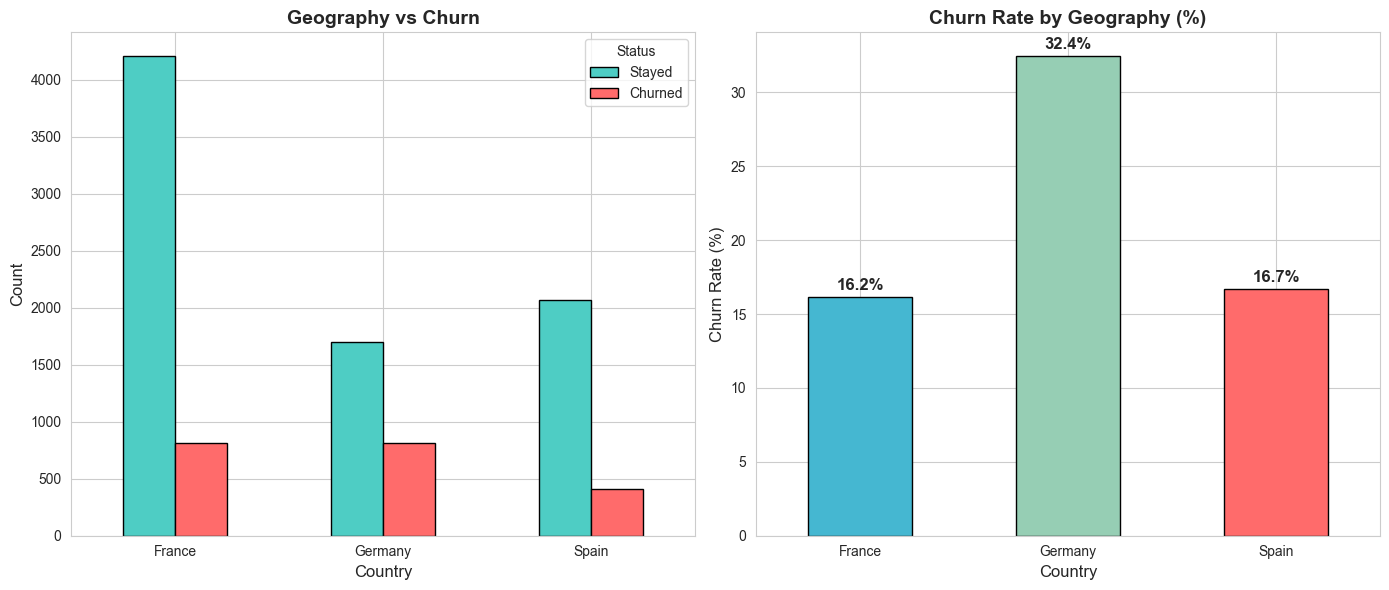

Observation: Germany has the highest churn rate!


In [9]:
# ============================
# Step 9: Geography vs Churn
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
pd.crosstab(df_clean['Geography'], df_clean['Exited']).plot(kind='bar', ax=axes[0],
    color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
axes[0].set_title('Geography vs Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Country', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['Stayed', 'Churned'], title='Status')

# Churn rate by geography
churn_rate = df_clean.groupby('Geography')['Exited'].mean() * 100
churn_rate.plot(kind='bar', ax=axes[1], color=['#45B7D1', '#96CEB4', '#FF6B6B'], 
                edgecolor='black')
axes[1].set_title('Churn Rate by Geography (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Country', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Add percentage labels
for i, v in enumerate(churn_rate.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Observation: Germany has the highest churn rate!")

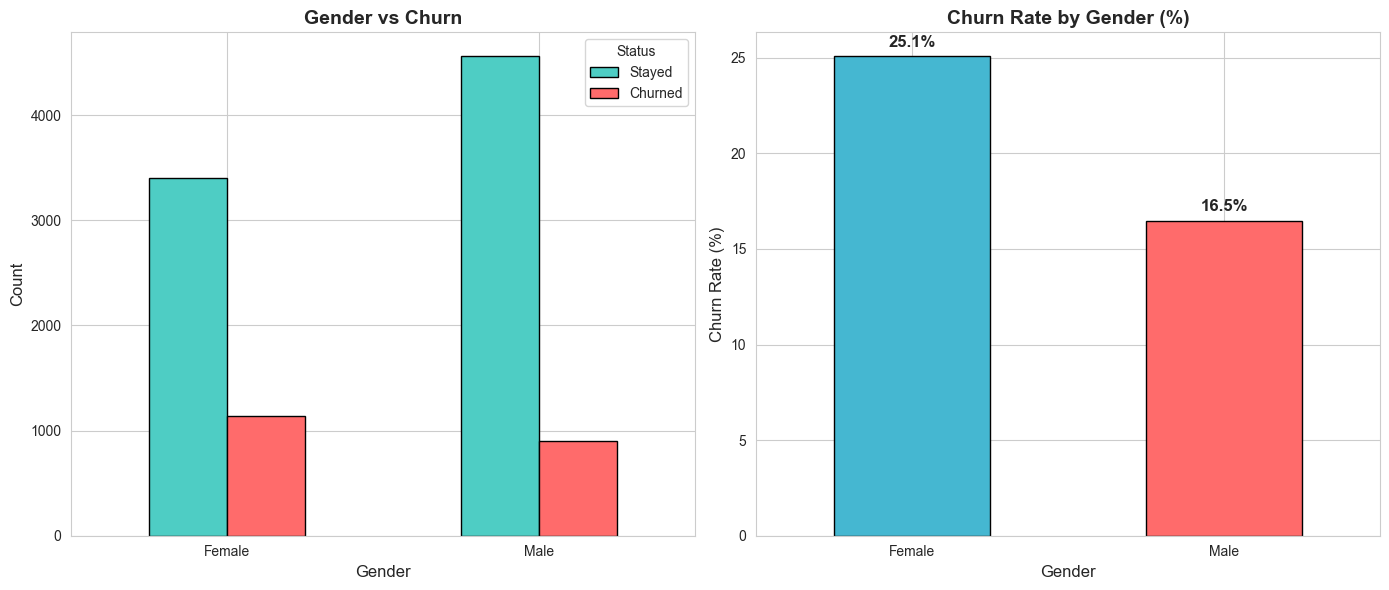

Observation: Female customers have a higher churn rate than males!


In [10]:
# ============================
# Step 10: Gender vs Churn
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
pd.crosstab(df_clean['Gender'], df_clean['Exited']).plot(kind='bar', ax=axes[0],
    color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
axes[0].set_title('Gender vs Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['Stayed', 'Churned'], title='Status')

# Churn rate by gender
churn_rate = df_clean.groupby('Gender')['Exited'].mean() * 100
churn_rate.plot(kind='bar', ax=axes[1], color=['#45B7D1', '#FF6B6B'], edgecolor='black')
axes[1].set_title('Churn Rate by Gender (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for i, v in enumerate(churn_rate.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Observation: Female customers have a higher churn rate than males!")

C:\Users\home computers\AppData\Local\Temp\ipykernel_11588\3880435079.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Exited', y='Age', ax=axes[1],


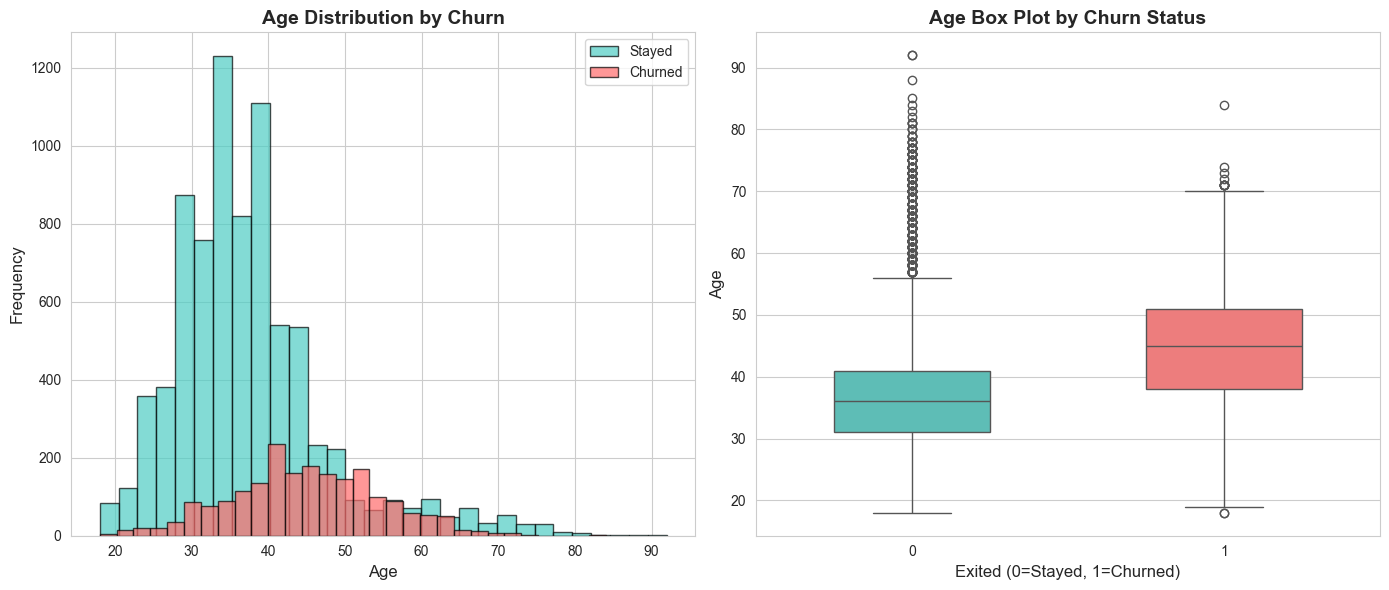

Average age of stayed customers: 37.4
Average age of churned customers: 44.8

Observation: Older customers are more likely to churn!


In [11]:
# ============================
# Step 11: Age Distribution by Churn Status
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
df_clean[df_clean['Exited'] == 0]['Age'].hist(bins=30, ax=axes[0], alpha=0.7,
    color='#4ECDC4', edgecolor='black', label='Stayed')
df_clean[df_clean['Exited'] == 1]['Age'].hist(bins=30, ax=axes[0], alpha=0.7,
    color='#FF6B6B', edgecolor='black', label='Churned')
axes[0].set_title('Age Distribution by Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()

# Box Plot
sns.boxplot(data=df_clean, x='Exited', y='Age', ax=axes[1],
            palette=['#4ECDC4', '#FF6B6B'], width=0.5)
axes[1].set_title('Age Box Plot by Churn Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Exited (0=Stayed, 1=Churned)', fontsize=12)
axes[1].set_ylabel('Age', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Average age of stayed customers: {df_clean[df_clean['Exited']==0]['Age'].mean():.1f}")
print(f"Average age of churned customers: {df_clean[df_clean['Exited']==1]['Age'].mean():.1f}")
print("\nObservation: Older customers are more likely to churn!")

C:\Users\home computers\AppData\Local\Temp\ipykernel_11588\2882538107.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Exited', y='Balance', ax=axes[0],
C:\Users\home computers\AppData\Local\Temp\ipykernel_11588\2882538107.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Exited', y='EstimatedSalary', ax=axes[1],


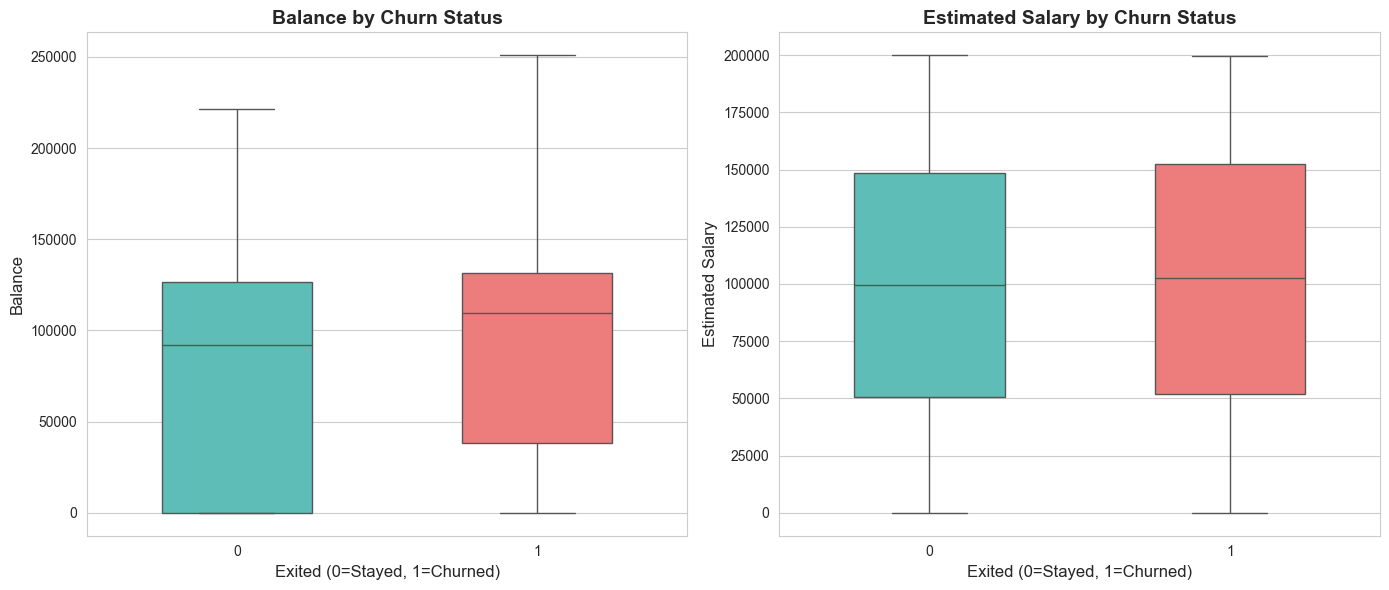

In [12]:
# ============================
# Step 12: Balance and Estimated Salary Analysis
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Balance Box Plot
sns.boxplot(data=df_clean, x='Exited', y='Balance', ax=axes[0],
            palette=['#4ECDC4', '#FF6B6B'], width=0.5)
axes[0].set_title('Balance by Churn Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Exited (0=Stayed, 1=Churned)', fontsize=12)
axes[0].set_ylabel('Balance', fontsize=12)

# Estimated Salary Box Plot
sns.boxplot(data=df_clean, x='Exited', y='EstimatedSalary', ax=axes[1],
            palette=['#4ECDC4', '#FF6B6B'], width=0.5)
axes[1].set_title('Estimated Salary by Churn Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Exited (0=Stayed, 1=Churned)', fontsize=12)
axes[1].set_ylabel('Estimated Salary', fontsize=12)

plt.tight_layout()
plt.show()

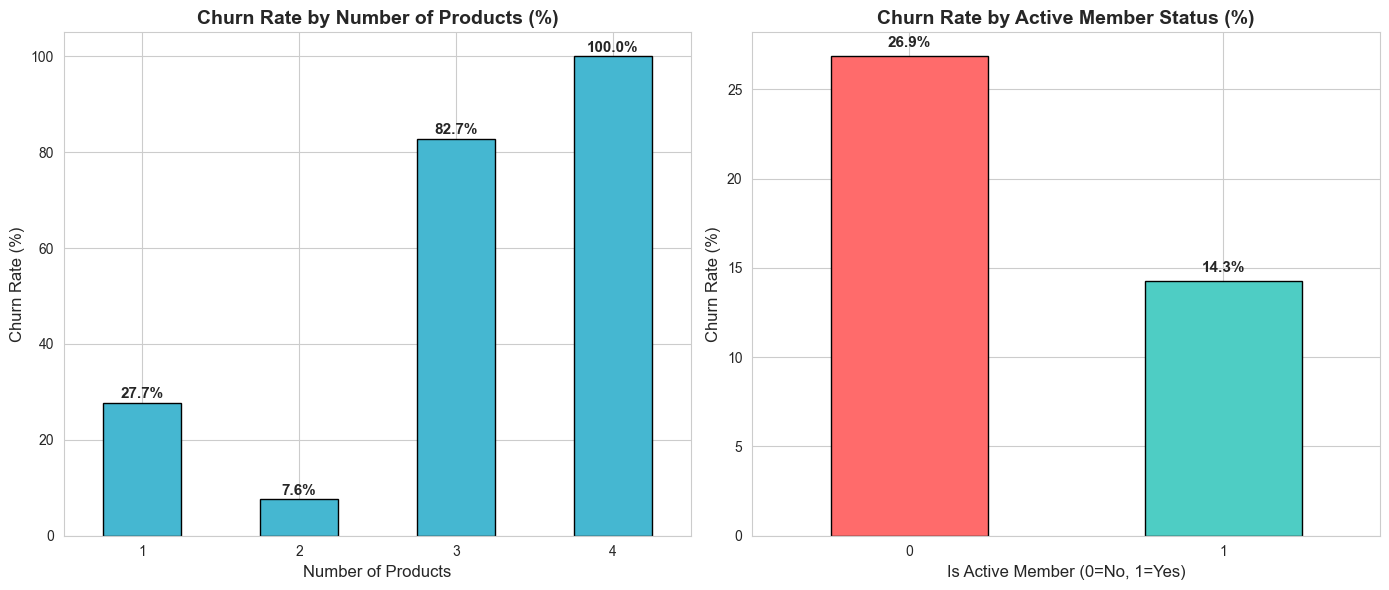

Observations:
- Customers with 3 or 4 products have very high churn rates!
- Inactive members churn more than active members.


In [13]:
# ============================
# Step 13: NumOfProducts and IsActiveMember vs Churn
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# NumOfProducts vs Churn
churn_by_products = df_clean.groupby('NumOfProducts')['Exited'].mean() * 100
churn_by_products.plot(kind='bar', ax=axes[0], color='#45B7D1', edgecolor='black')
axes[0].set_title('Churn Rate by Number of Products (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Products', fontsize=12)
axes[0].set_ylabel('Churn Rate (%)', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

for i, v in enumerate(churn_by_products.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# IsActiveMember vs Churn
churn_by_active = df_clean.groupby('IsActiveMember')['Exited'].mean() * 100
churn_by_active.plot(kind='bar', ax=axes[1], color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[1].set_title('Churn Rate by Active Member Status (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Is Active Member (0=No, 1=Yes)', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for i, v in enumerate(churn_by_active.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Observations:")
print("- Customers with 3 or 4 products have very high churn rates!")
print("- Inactive members churn more than active members.")

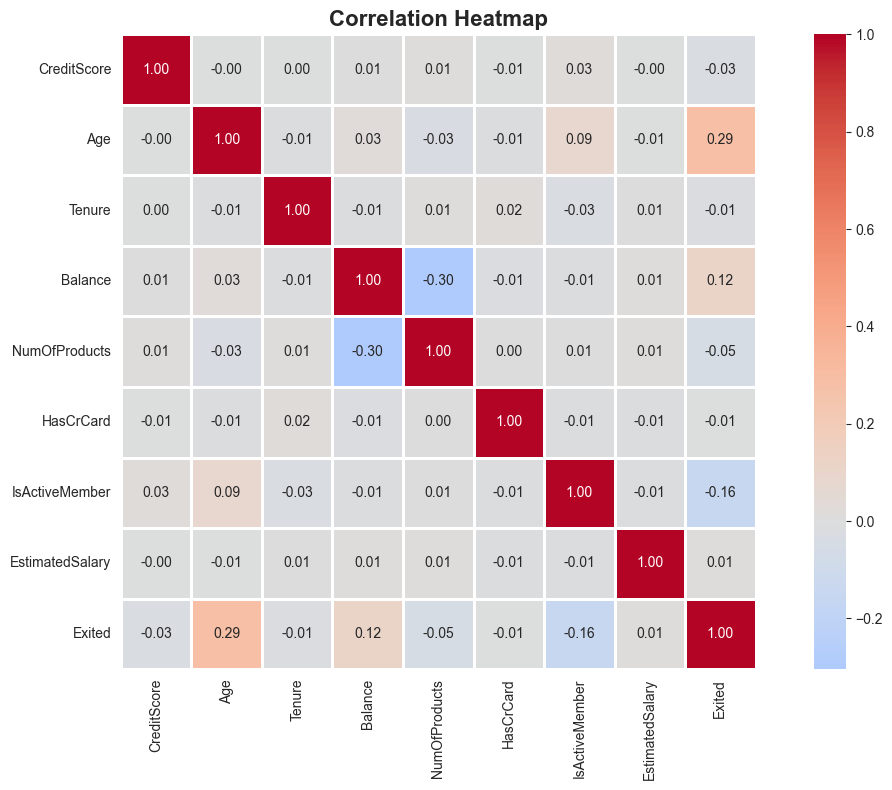

In [14]:
# ============================
# Step 14: Correlation Heatmap
# ============================

plt.figure(figsize=(12, 8))

numeric_df = df_clean.select_dtypes(include='number')
correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    fmt='.2f',
    annot_kws={'fontsize': 10}
)

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Building

### Steps:
1. Encode categorical features (Geography, Gender) using Label Encoding and One-Hot Encoding
2. Scale numerical features using StandardScaler
3. Split data into training (80%) and testing (20%)
4. Train Logistic Regression model
5. Train Decision Tree model
6. Train Random Forest model
7. Compare all models and analyze feature importance

In [19]:
# ============================
# Step 15: Encode Categorical Features
# ============================

df_model = df_clean.copy()

# Gender: Label Encoding (Male=1, Female=0)
le = LabelEncoder()
df_model['Gender'] = le.fit_transform(df_model['Gender'])
print("Gender encoded: Female=0, Male=1")

# Geography: One-Hot Encoding
df_model = pd.get_dummies(df_model, columns=['Geography'], drop_first=True)
print("Geography encoded using One-Hot Encoding")
print()

print("Columns after encoding:")
for i, col in enumerate(df_model.columns, 1):
    print(f"  {i}. {col}")
print()

print("First 5 Rows after encoding:")
df_model.head()

Gender encoded: Female=0, Male=1
Geography encoded using One-Hot Encoding

Columns after encoding:
  1. CreditScore
  2. Gender
  3. Age
  4. Tenure
  5. Balance
  6. NumOfProducts
  7. HasCrCard
  8. IsActiveMember
  9. EstimatedSalary
  10. Exited
  11. Geography_Germany
  12. Geography_Spain

First 5 Rows after encoding:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [20]:
# ============================
# Step 16: Split Data into Training and Testing Sets
# ============================

# Features (X) - all columns except 'Exited'
X = df_model.drop('Exited', axis=1)

# Target (y) - 'Exited' column
y = df_model['Exited']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Split and Scaling Complete!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Data Split and Scaling Complete!
Training samples: 8000
Testing samples: 2000


In [21]:
# ============================
# Step 17: Train Logistic Regression Model
# ============================

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"\nAccuracy: {lr_accuracy * 100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_predictions, target_names=['Stayed', 'Churned']))

LOGISTIC REGRESSION RESULTS

Accuracy: 81.10%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.83      0.96      0.89      1607
     Churned       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



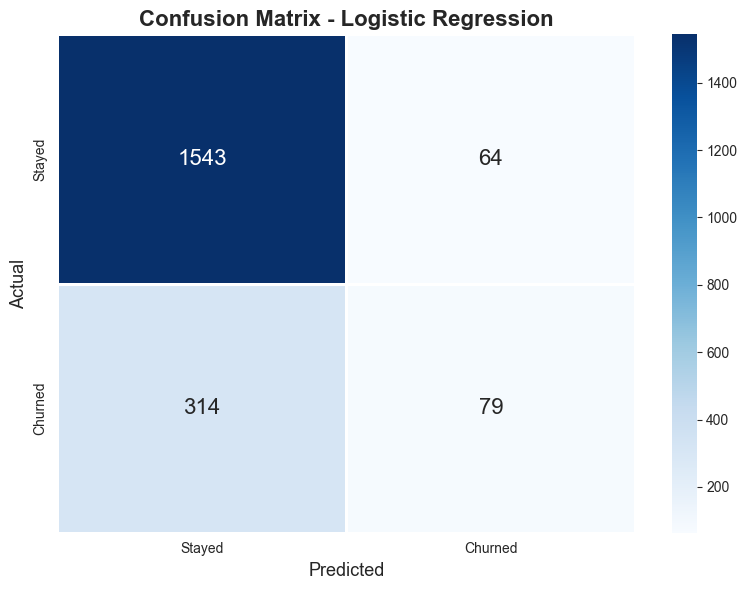

In [22]:
# ============================
# Step 18: Confusion Matrix - Logistic Regression
# ============================

plt.figure(figsize=(8, 6))

cm_lr = confusion_matrix(y_test, lr_predictions)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            annot_kws={'fontsize': 16}, linewidths=2)

plt.title('Confusion Matrix - Logistic Regression', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
# ============================
# Step 19: Train Decision Tree Classifier
# ============================

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("=" * 50)
print("DECISION TREE RESULTS")
print("=" * 50)
print(f"\nAccuracy: {dt_accuracy * 100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, dt_predictions, target_names=['Stayed', 'Churned']))

DECISION TREE RESULTS

Accuracy: 85.75%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1607
     Churned       0.76      0.40      0.52       393

    accuracy                           0.86      2000
   macro avg       0.82      0.68      0.72      2000
weighted avg       0.85      0.86      0.84      2000



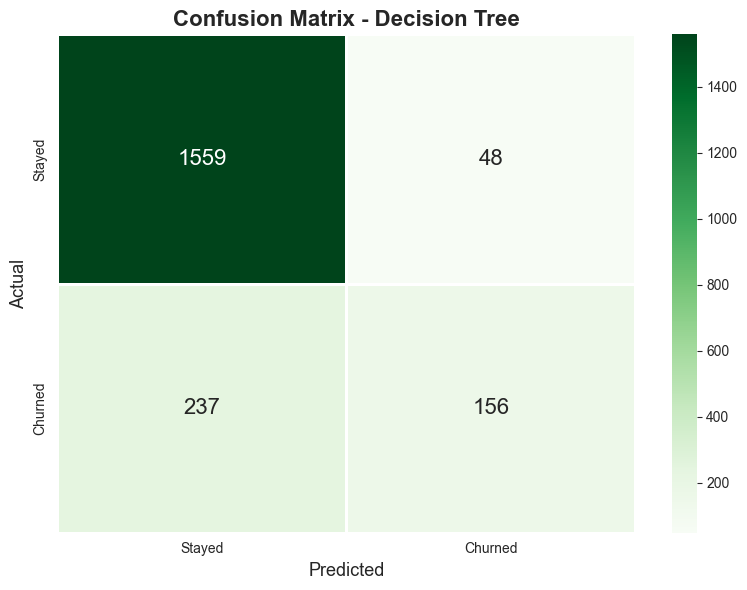

In [24]:
# ============================
# Step 20: Confusion Matrix - Decision Tree
# ============================

plt.figure(figsize=(8, 6))

cm_dt = confusion_matrix(y_test, dt_predictions)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            annot_kws={'fontsize': 16}, linewidths=2)

plt.title('Confusion Matrix - Decision Tree', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
# ============================
# Step 21: Train Random Forest Classifier
# ============================

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"\nAccuracy: {rf_accuracy * 100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_predictions, target_names=['Stayed', 'Churned']))

RANDOM FOREST RESULTS

Accuracy: 86.45%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1607
     Churned       0.76      0.45      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.86      0.86      0.85      2000



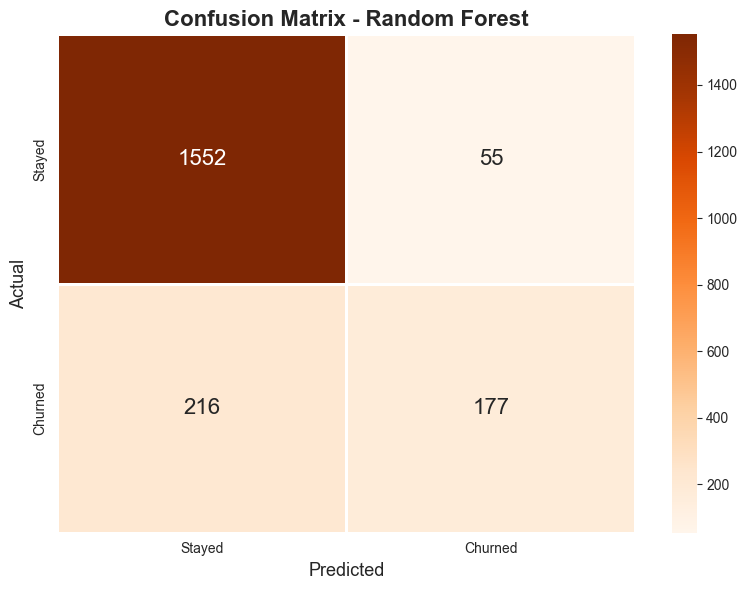

In [26]:
# ============================
# Step 22: Confusion Matrix - Random Forest
# ============================

plt.figure(figsize=(8, 6))

cm_rf = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            annot_kws={'fontsize': 16}, linewidths=2)

plt.title('Confusion Matrix - Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.tight_layout()
plt.show()

MODEL COMPARISON

Logistic Regression Accuracy: 81.10%
Decision Tree Accuracy:       85.75%
Random Forest Accuracy:       86.45%


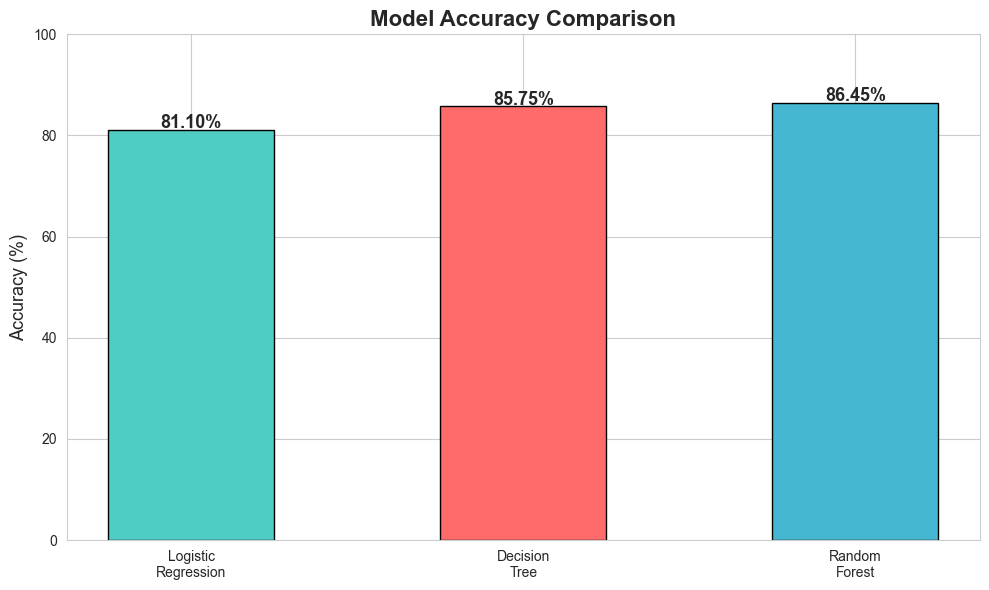


Best Performing Model: Random
Forest with 86.45% accuracy


In [27]:
# ============================
# Step 23: Model Comparison
# ============================

print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"\nLogistic Regression Accuracy: {lr_accuracy * 100:.2f}%")
print(f"Decision Tree Accuracy:       {dt_accuracy * 100:.2f}%")
print(f"Random Forest Accuracy:       {rf_accuracy * 100:.2f}%")

# Visual Comparison
plt.figure(figsize=(10, 6))

models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
accuracies = [lr_accuracy * 100, dt_accuracy * 100, rf_accuracy * 100]
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', fontsize=13, fontweight='bold')

plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=13)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Best model
best_model = models[accuracies.index(max(accuracies))]
print(f"\nBest Performing Model: {best_model} with {max(accuracies):.2f}% accuracy")

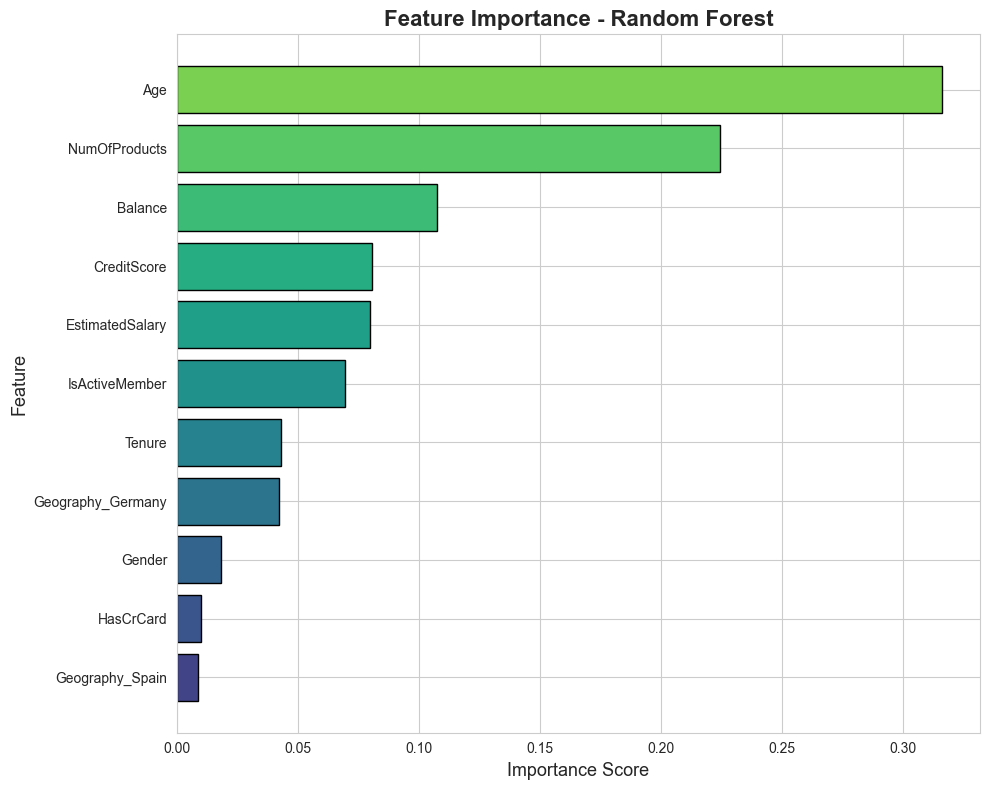


Top 5 Most Important Features for Churn Prediction:
--------------------------------------------------
  1. EstimatedSalary (Importance: 0.0798)
  2. CreditScore (Importance: 0.0805)
  3. Balance (Importance: 0.1077)
  4. NumOfProducts (Importance: 0.2246)
  5. Age (Importance: 0.3162)


In [28]:
# ============================
# Step 24: Feature Importance Analysis
# ============================
# Understanding which features influence churn the most

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(feature_importance)))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color=colors, edgecolor='black')
plt.title('Feature Importance - Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features for Churn Prediction:")
print("-" * 50)
top_5 = feature_importance.tail(5)
for rank, (_, row) in enumerate(top_5.iterrows(), 1):
    print(f"  {rank}. {row['Feature']} (Importance: {row['Importance']:.4f})")

## Conclusion

### Key Findings from Customer Churn Prediction:

1. **Dataset Overview**: The dataset contains 10,000 bank customers with 11 features. No missing values were found. The dataset is imbalanced with approximately 80% stayed and 20% churned customers.

2. **Key Observations from EDA**:
   - Germany has the highest churn rate among all countries
   - Female customers churn more than male customers
   - Older customers (age 40-60) are more likely to churn
   - Inactive members have higher churn rates
   - Customers with 3 or 4 products have very high churn rates

3. **Model Performance**:
   - Three models were trained and compared
   - Random Forest achieved the best accuracy
   - All models performed reasonably well on this dataset

4. **Feature Importance**:
   - Age is the most important predictor of churn
   - Number of Products, Balance, and Geography also play significant roles
   - IsActiveMember status impacts churn prediction

5. **Business Recommendations**:
   - Focus retention efforts on older customers (40-60 age group)
   - Pay special attention to German market - highest churn rate
   - Encourage customers to remain active members
   - Monitor customers with multiple products as they have higher churn risk
   - Create special retention programs for female customers